In [1]:
#PCA on dummy student data, with covariance matirx

In [2]:
import pandas as pd 
import numpy as np

In [3]:
#Step1: create dummy data
data={
    "Maths":[95,88,92,70,68,75,45,50,40,60],
    "Science":[90,85,94,72,65,78,50,55,42,58],
    "English":[60,65,62,80,82,75,88,84,90,70],
    "Hindi":[58,63,60,78,85,72,90,82,88,68]
}


In [4]:
df=pd.DataFrame(data)
print(df)

   Maths  Science  English  Hindi
0     95       90       60     58
1     88       85       65     63
2     92       94       62     60
3     70       72       80     78
4     68       65       82     85
5     75       78       75     72
6     45       50       88     90
7     50       55       84     82
8     40       42       90     88
9     60       58       70     68


In [7]:
#Display Covariance matrix
cov_matrix=df.cov()
print("\nCovaraince Matrix:")
print(cov_matrix)


Covaraince Matrix:
              Maths     Science     English       Hindi
Maths    384.233333  343.255556 -194.422222 -205.688889
Science  343.255556  314.988889 -170.600000 -182.177778
English -194.422222 -170.600000  118.266667  127.400000
Hindi   -205.688889 -182.177778  127.400000  140.488889


In [12]:
#Add a "Result" column
df['Result']=((df['Maths']>=60)|(df['Science']>=60))&((df['English']>=60)|(df['Hindi']>=60)).astype(int)
print(df)

   Maths  Science  English  Hindi  Result
0     95       90       60     58    True
1     88       85       65     63    True
2     92       94       62     60    True
3     70       72       80     78    True
4     68       65       82     85    True
5     75       78       75     72    True
6     45       50       88     90   False
7     50       55       84     82   False
8     40       42       90     88   False
9     60       58       70     68    True


In [13]:
#Save to CSV (optional)
df.to_csv("student_marks.csv",index=False)

In [14]:
#2.PCA + lOGISTIC REGRESSION
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 

In [15]:
numerical_cols=['Maths','Science','English','Hindi']

In [19]:
#3.Handle Misisng Values
imputer=SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(df[numerical_cols])
data_clean=pd.DataFrame(data_imputed,columns=numerical_cols)


In [21]:
#4.Standardize
scaler=StandardScaler()
data_scaled =scaler.fit_transform(data_clean)

In [23]:
#5Apply PCA
pca=PCA(n_components=4)
data_pca=pca.fit_transform(data_scaled)

In [25]:
#6.Explained Variance 
explained_variance = pca.explained_variance_ratio_
cumulative_variance=np.cumsum(explained_variance)

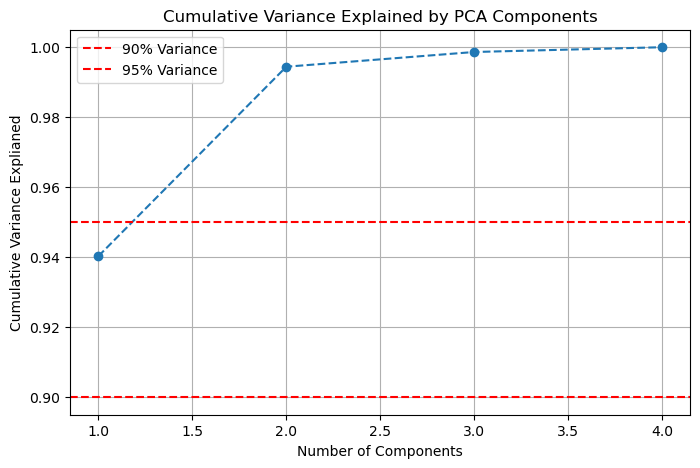

In [27]:
#7.Plot cumulative Variance
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,marker='o',linestyle='--')
plt.title('Cumulative Variance Explained by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explianed')
plt.axhline(y=0.9,color='r',linestyle='--',label='90% Variance')
plt.axhline(y=0.95,color='r',linestyle='--',label='95% Variance')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
print("\nExplained Varaince Ratio:")
print(explained_variance.round(3))


Explained Varaince Ratio:
[0.94  0.054 0.004 0.001]


In [30]:
print("\nCumulative Variance")
print(cumulative_variance.round(3))


Cumulative Variance
[0.94  0.994 0.999 1.   ]


In [31]:
#9.Feature Loadings 
loadings=pd.DataFrame(pca.components_.T,#transpose to get features as rows
                      columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                      index=numerical_cols
                      )

In [32]:
print("\nFeature Loadings:")
print(loadings.round(3))


Feature Loadings:
           PC1    PC2    PC3    PC4
Maths   -0.503 -0.440  0.535 -0.517
Science -0.497 -0.554 -0.529  0.408
English  0.503 -0.444 -0.457 -0.584
Hindi    0.497 -0.550  0.474  0.475


In [34]:
#10.ADD on: logistic Regression on PCA-Reduced Data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [35]:
#Find the index of the first component where cumulative variance is >=0.95
index_of_95=np.argmax(cumulative_variance>=0.95)
if cumulative_variance[index_of_95]>=0.95:
    n_opt = index_of_95 +1
else:
    #If the target eas NOT reached, use all available components 
    n_opt = len(explained_variance)

In [36]:
print(f"\nOptimal number of components to retain 95% varaiance:{n_opt}")

#Use the optimally reduced data for modellinf
x_pca_reduced = data_pca[:,:n_opt]
y=df['Result']


Optimal number of components to retain 95% varaiance:2


In [37]:
X_train, X_test, y_train,y_test=train_test_split(
    x_pca_reduced,y,test_size=0.3,random_state=42,stratify=y)

In [38]:
#Initialize and train the Logistic Regression model
log_reg =LogisticRegression(solver='liblinear',random_state=42,max_iter=1000)
log_reg.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [39]:
y_pred=log_reg.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Model Accuracy:{accuracy:.4f}")

Model Accuracy:0.6667
